In [ ]:
import os
import random
import matplotlib.pyplot as plt
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from PIL import Image
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms as T

# --- Configuration ---
# TODO: Update these paths to your actual data locations
BASE_DATA_DIR = '../data' # Assume data folders are in the same directory as the script
TRAIN_DIR = os.path.join(BASE_DATA_DIR, 'train')
TRAIN_IMG_DIR = os.path.join(TRAIN_DIR, 'input')
TRAIN_GT_DIR = os.path.join(TRAIN_DIR, 'GT')

TEST_DIR = os.path.join(BASE_DATA_DIR, 'test')
TEST_IMG_DIR = os.path.join(TEST_DIR, 'input')
TEST_GT_DIR = os.path.join(TEST_DIR, 'GT')

# TODO: Update this to your desired output directory
OUTPUT_DIR = './output_results'
MODEL_SAVE_PATH = os.path.join(OUTPUT_DIR, 'models')
VALIDATION_RESULTS_PATH = os.path.join(OUTPUT_DIR, 'validation_images')
TEST_PREDICTIONS_COMPARE_PATH = os.path.join(OUTPUT_DIR, 'compare')
# TEST_PREDICTIONS_PATH = os.path.join(OUTPUT_DIR, 'predict') # As per homework requirements -> output_results
TEST_PREDICTIONS_PATH = os.path.join(TEST_DIR, 'predict') # As per homework requirements -> data/test

# Make sure output directories exist
os.makedirs(MODEL_SAVE_PATH, exist_ok=True)
os.makedirs(VALIDATION_RESULTS_PATH, exist_ok=True)
os.makedirs(TEST_PREDICTIONS_PATH, exist_ok=True)
os.makedirs(TEST_PREDICTIONS_COMPARE_PATH, exist_ok=True)


# Hyperparameters (TODO: Tune these)
IMG_SIZE = (256, 256) # Input image size
BATCH_SIZE = 16
LEARNING_RATE = 1e-4
NUM_EPOCHS = 25 # Adjust as needed, homework asks for val images at epoch 5, 10, 20
VALIDATION_SPLIT = 0.2 # 20% of training data for validation
RANDOM_SEED = 42

# Based on HW4_題目.pdf, page 11-13
# IMPORTANT: Ensure your GT masks use these exact RGB values for each class.
# The order also defines the class IDs (0, 1, 2, 3, 4)
CLASSES = ["Cushion", "Armrest", "Leg", "Seat Base", "Backrest", "Background"] # Added Background
CLASS_COLORS_RGB = [
    (60, 180, 90),  # Cushion (Green)
    (110, 40, 40),   # Armrest (Brown)
    (50, 10, 70),    # Leg (Black) - Note: PDF says (50,10,70) but often "black" is closer to (0,0,0)
    (180, 200, 60), # Seat Base (Yellow)
    (100, 100, 100), # Backrest (Gray)
]
NUM_CLASSES = len(CLASS_COLORS_RGB) # Number of actual object classes
MODEL_NUM_OUTPUT_CLASSES = NUM_CLASSES + 1 # Including background class for segmentation

# Add a background color (e.g., pure black or white, not present in the foreground objects)
# This helps the model learn pixels that don't belong to any defined sofa part.
# If your masks already have a consistent background color that is NOT one of the above,
# you might not need to explicitly add one here, but then MODEL_NUM_OUTPUT_CLASSES should be NUM_CLASSES.
# For this example, let's assume background is (255, 255, 255) and is the last class.
BACKGROUND_COLOR_RGB = (255, 255, 255)
ALL_COLORS_RGB = CLASS_COLORS_RGB + [BACKGROUND_COLOR_RGB]


COLOR_TO_CLASS_ID = {color: i for i, color in enumerate(ALL_COLORS_RGB)}
CLASS_ID_TO_COLOR = {i: color for i, color in enumerate(ALL_COLORS_RGB)}

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {DEVICE}")

# Set random seeds for reproducibility
random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)
torch.manual_seed(RANDOM_SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_SEED)
    
    
ORIGIN_SIZE = []

Using device: cuda


## decoder-encoder

In [52]:
def rgb_to_mask(rgb_mask_img, color_to_class_id_map, target_size):
    """Converts an RGB mask image to a 2D tensor of class IDs."""
    # Ensure mask is the correct size
    if rgb_mask_img.size != target_size:
        rgb_mask_img = rgb_mask_img.resize(target_size, Image.NEAREST)

    mask_np = np.array(rgb_mask_img)
    h, w, _ = mask_np.shape
    class_mask = np.full((h, w), MODEL_NUM_OUTPUT_CLASSES -1, dtype=np.int64) # Default to background 初始化空陣列

    for color, class_id in color_to_class_id_map.items():
        matches = np.all(mask_np == np.array(color).reshape(1, 1, 3), axis=2) # 返回一個形狀為 (h, w) 的布林陣列 matches，其中每個位置是 True 或 False
        class_mask[matches] = class_id
    return torch.from_numpy(class_mask).long()                        # 將 NumPy 陣列 class_mask 轉換為 PyTorch 張量

def mask_to_rgb(pred_mask_tensor, class_id_to_color_map):
    """Converts a class ID tensor mask back to an RGB image."""
    if pred_mask_tensor.ndim == 3 and pred_mask_tensor.shape[0] == 1: # (1, H, W) ->（即單通道的3D張量）
        pred_mask_tensor = pred_mask_tensor.squeeze(0)                # 壓縮成(H, W)的2D張量
    pred_mask_np = pred_mask_tensor.cpu().numpy().astype(np.uint8)
    h, w = pred_mask_np.shape
    rgb_output = np.zeros((h, w, 3), dtype=np.uint8)                  # 初始化空的RGB圖像 (3: 3通道RGB)，每個像素將初始化為黑色（即Background(255, 255, 255)）

    for class_id, color in class_id_to_color_map.items():
        rgb_output[pred_mask_np == class_id] = color                  # red_mask_np == class_id會產生一個布林陣列，為True(1)則賦予對應color
    return Image.fromarray(rgb_output)                                # 將NumPy陣列rgb_output轉換回PIL圖像


## save prediction image

In [53]:
def replace_background_to_transparent(image):
    
    # 將圖像轉換為 RGBA 格式，這樣就有 alpha 通道
    img = image.convert("RGBA")
    
    # 將圖片轉為 numpy 陣列
    img_data = np.array(img)

    # 白色像素 (255, 255, 255) 設為透明
    black_pixels = np.all(img_data[:, :, :3] == [255, 255, 255], axis=2)
    
    # 將符合條件的黑色像素設為透明 (將 alpha 通道設為 0)
    img_data[black_pixels, 3] = 0
    
    # 將處理後的圖片轉回為 PIL 物件
    new_img = Image.fromarray(img_data, "RGBA")
    
    return new_img

In [54]:
def save_validation_image(epoch, input_imgs, pred_masks, gt_masks, original_sizes, save_dir):
    """Saves a comparison of input, prediction, and ground truth for each epoch."""
    
    fig, ax = plt.subplots(3, 3, figsize=(15, 15))  # Create a 3x3 grid of images
    ax = ax.ravel()  # Flatten the axes array for easy indexing
    # print(original_sizes)

    for i, img in enumerate(input_imgs):
        
        original_size = original_sizes[i] 
        # Prepare input image (denormalize and plot)
        input_img = img.cpu().numpy().transpose(1, 2, 0)
        mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
        std = np.array([0.229, 0.224, 0.225])  # ImageNet std
        input_img = std * input_img + mean
        input_img = np.clip(input_img, 0, 1)
        # 轉換為 [0, 255] 範圍，並轉換為 uint8 類型以便於顯示
        input_img = (input_img * 255).clip(0, 255).astype(np.uint8)


        # Convert the masks to RGB
        pred_rgb = mask_to_rgb(pred_masks[i], CLASS_ID_TO_COLOR)
        gt_rgb = mask_to_rgb(gt_masks[i], CLASS_ID_TO_COLOR)

        # resize result
        input_img_resized = Image.fromarray(input_img).resize(original_size, Image.NEAREST)  # numpy to PIL and resize
        pred_rgb_resized = pred_rgb.resize(original_size, Image.NEAREST)
        gt_rgb_resized = gt_rgb.resize(original_size, Image.NEAREST)

        # Apply transparency to black pixels in predicted and ground truth masks
        pred_rgba = replace_background_to_transparent(pred_rgb_resized)
        gt_rgba = replace_background_to_transparent(gt_rgb_resized)



        # Set titles for the images and arrange them vertically
        # Input Image (Top)
        ax[i].imshow(input_img_resized)
        ax[i].set_title(f"Input Image (Epoch {epoch})")
        ax[i].axis('off')

        # Predicted Mask (Middle)
        ax[i + 1 * 3].imshow(pred_rgba)
        ax[i + 1 * 3].set_title(f"Predicted Mask (Epoch {epoch})")
        ax[i + 1 * 3].axis('off')

        # Ground Truth Mask (Bottom)
        ax[i + 2 * 3].imshow(gt_rgba)
        ax[i + 2 * 3].set_title(f"Ground Truth Mask (Epoch {epoch})")
        ax[i + 2 * 3].axis('off')

    # Save the image
    plt.suptitle(f"Validation Results - Epoch {epoch}", fontsize=16)
    save_path = os.path.join(save_dir, f"epoch_{epoch}_validation.png")
    plt.tight_layout()
    plt.subplots_adjust(top=0.9)  # Adjust to fit the title
    plt.savefig(save_path)
    plt.close(fig)

    print(f"Saved validation image to {save_path}")


## Dataset Class

In [55]:
class SofaDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None, target_size=(256,256)):
        self.image_paths = image_paths
        self.mask_paths = mask_paths
        self.transform = transform
        self.target_size = target_size

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        mask_path = self.mask_paths[idx]

        image = Image.open(img_path).convert("RGB")
        mask_rgb = Image.open(mask_path).convert("RGB")

        # Convert RGB mask to class ID mask
        # This happens before other mask transformations if they expect a single channel tensor
        mask = rgb_to_mask(mask_rgb, COLOR_TO_CLASS_ID, self.target_size)


        if self.transform:
            image = self.transform(image)

        return image, mask


### Transforms - Preprocess

In [56]:

# (As per user request: import torchvision.transforms as T做尺寸調條、tensor、正規化)
image_transforms = T.Compose([
    T.Resize(IMG_SIZE),
    T.ToTensor(),
    T.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]) # ImageNet stats
])



### create model - U-Net

In [57]:
# TODO: Replace this with VLTSeg or ONE-PEACE model loading and adaptation
class DoubleConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_channels, out_channels, kernel_size=3, padding=1),
            nn.BatchNorm2d(out_channels),
            nn.ReLU(inplace=True)
        )
    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.mpconv = nn.Sequential(
            nn.MaxPool2d(2),
            DoubleConv(in_channels, out_channels)
        )
    def forward(self, x):
        return self.mpconv(x)

class Up(nn.Module):
    def __init__(self, in_channels, out_channels, bilinear=True):
        super().__init__()
        if bilinear:
            self.up = nn.Upsample(scale_factor=2, mode='bilinear', align_corners=True)
        else:
            self.up = nn.ConvTranspose2d(in_channels // 2, in_channels // 2, kernel_size=2, stride=2)
        self.conv = DoubleConv(in_channels, out_channels)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2, diffY // 2, diffY - diffY // 2])
        x = torch.cat([x2, x1], dim=1)
        return self.conv(x)

class OutConv(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.conv = nn.Conv2d(in_channels, out_channels, kernel_size=1)
    def forward(self, x):
        return self.conv(x)

class UNet(nn.Module):
    def __init__(self, n_channels, n_classes, bilinear=True):
        super(UNet, self).__init__()
        self.n_channels = n_channels
        self.n_classes = n_classes
        self.bilinear = bilinear

        self.inc = DoubleConv(n_channels, 64)
        self.down1 = Down(64, 128)
        self.down2 = Down(128, 256)
        self.down3 = Down(256, 512)
        self.down4 = Down(512, 512)
        self.up1 = Up(1024, 256, bilinear)
        self.up2 = Up(512, 128, bilinear)
        self.up3 = Up(256, 64, bilinear)
        self.up4 = Up(128, 64, bilinear)
        self.outc = OutConv(64, n_classes)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)
        x5 = self.down4(x4)
        x = self.up1(x5, x4)
        x = self.up2(x, x3)
        x = self.up3(x, x2)
        x = self.up4(x, x1)
        logits = self.outc(x)
        return logits


### Evaluation Metrics (IoU and PSNR)

In [58]:

def calculate_iou(pred_mask, true_mask, num_classes):
    """Calculates IoU per class and mIoU."""
    pred_mask = pred_mask.cpu().numpy()
    true_mask = true_mask.cpu().numpy()
    ious = []
    # Ignore background class for mIoU if it's the last one or not relevant
    # classes_to_evaluate = num_classes -1 # If background is last and not evaluated for specific tasks
    classes_to_evaluate = num_classes

    for cls in range(classes_to_evaluate):
        pred_inds = (pred_mask == cls)
        target_inds = (true_mask == cls)
        intersection = (pred_inds[target_inds]).sum()               # 算預測和真實標註在當前類別上的交集
        union = pred_inds.sum() + target_inds.sum() - intersection  # 計算兩者聯集=(A+B)-(A交集B)
        if union == 0:                                              # 該類別在預測和真實標註中都完全沒有出現，這是 IoU 無效的情況
            ious.append(float('nan'))  # Or 0, or 1 if no GT and no pred
        else:
            ious.append(float(intersection) / float(union))
    miou = np.nanmean(ious)                                         # 計算所有類別的 IoU 平均值，忽略 nan 值
    return ious, miou

def calculate_psnr(pred_rgb_img, true_rgb_img):
    """Calculates PSNR between two RGB images (PIL Images or NumPy arrays)."""
    if isinstance(pred_rgb_img, Image.Image):
        pred_rgb_img = np.array(pred_rgb_img).astype(np.float32)
    if isinstance(true_rgb_img, Image.Image):
        true_rgb_img = np.array(true_rgb_img).astype(np.float32)

    mse = np.mean((true_rgb_img - pred_rgb_img) ** 2)
    if mse == 0:
        return float('inf')
    max_pixel = 255.0
    psnr = 20 * np.log10(max_pixel / np.sqrt(mse))
    return psnr


### Training

In [59]:
def train_model(model, train_loader, criterion, optimizer, device):
    model.train()
    running_loss = 0.0

    for i, (images, masks) in enumerate(train_loader):
        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()
        outputs = model(images)  # outputs are (B, C, H, W)
        loss = criterion(outputs, masks)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * images.size(0)

        if (i + 1) % 20 == 0:  # Print every 20 batches
            print(f"  Batch {i+1}/{len(train_loader)}, Train Loss: {loss.item():.4f}")

    epoch_loss = running_loss / len(train_loader.dataset)
    return epoch_loss

In [60]:
def validate_model(model, val_loader, criterion, device, epoch, val_results_path):
    model.eval()
    val_running_loss = 0.0
    all_val_ious = []
    all_val_psnrs = []
    saved_val_image_this_epoch = False

    input_imgs = []  # List to store selected input images
    pred_masks = []  # List to store selected predicted masks
    gt_masks = []    # List to store selected ground truth masks
    original_sizes_to_save = [] # <-- New list to store original sizes
    
    
    with torch.no_grad():
        for i_val, (val_images, val_masks) in enumerate(val_loader):
            val_images = val_images.to(device)
            val_masks = val_masks.to(device)

            val_outputs = model(val_images)  # (B, C, H, W)
            val_loss = criterion(val_outputs, val_masks)
            val_running_loss += val_loss.item() * val_images.size(0)

            # Select 3 random indices
            indices_to_consider_for_saving = []
            if not saved_val_image_this_epoch and (epoch + 1) in [5, 10, 20] and val_images.size(0) >= 3:
                    # Take first 3 indices from the first batch (simplest) or random sample
                    # indices_to_consider_for_saving = random.sample(range(val_images.size(0)), 3) 
                    indices_to_consider_for_saving = [0, 1, 2] # Simpler: take first 3
                    print(f"Epoch {epoch+1}: Preparing validation images with indices {indices_to_consider_for_saving} from batch {i_val}")
                
            # Calculate IoU and PSNR for each image
            for j in range(val_images.size(0)):
                pred_mask_single = torch.argmax(val_outputs[j], dim=0)  # (H,W)
                true_mask_single = val_masks[j]  # (H,W)

                ious, _ = calculate_iou(pred_mask_single, true_mask_single, MODEL_NUM_OUTPUT_CLASSES)
                all_val_ious.append(ious)

                pred_rgb_single = mask_to_rgb(pred_mask_single, CLASS_ID_TO_COLOR)
                true_rgb_single = mask_to_rgb(true_mask_single, CLASS_ID_TO_COLOR)
                psnr = calculate_psnr(pred_rgb_single, true_rgb_single)
                all_val_psnrs.append(psnr)

                
                # Select 3 random data to visualization           
                if j in indices_to_consider_for_saving:
                    # Get original image path and size
                    original_val_idx_in_dataset = i_val * val_loader.batch_size + j 
                    # Ensure index is valid for the validation dataset
                    if original_val_idx_in_dataset < len(val_loader.dataset.image_paths):
                        original_val_img_path = val_loader.dataset.image_paths[original_val_idx_in_dataset]
                        try:
                            with Image.open(original_val_img_path) as img_orig_val:
                                original_val_size = img_orig_val.size # (width, height)
                            
                            # Add data to lists for saving
                            input_imgs.append(val_images[j].cpu())
                            pred_masks.append(pred_mask_single.cpu())
                            gt_masks.append(true_mask_single.cpu())
                            original_sizes_to_save.append(original_val_size) # <-- Store original size
                            
                            # Check if we have collected all 3 images
                            if len(input_imgs) == 3:
                                saved_val_image_this_epoch = True
                                # Clear the list so we don't select more indices from this batch
                                indices_to_consider_for_saving = [] 
                                print(f"Epoch {epoch+1}: Collected 3 images for validation saving.")

                        except Exception as e:
                            print(f"Error getting original size for validation image {original_val_img_path}: {e}")
                    else:
                         print(f"Warning: Index {original_val_idx_in_dataset} out of bounds for validation dataset paths.")


        if saved_val_image_this_epoch: # Should be true if epoch was 5, 10, or 20 and we found 3 images
            if len(input_imgs) == 3:
                print(f"Epoch {epoch+1}: Calling save_validation_image...")
                # Call the updated save function with the list of original sizes
                save_validation_image(epoch + 1, 
                                    input_imgs, 
                                    pred_masks, 
                                    gt_masks, 
                                    original_sizes_to_save, # <-- Pass list of sizes
                                    val_results_path)
            else:
                print(f"Warning: Epoch {epoch+1} was targetted for saving, but only {len(input_imgs)} images were collected.")



    epoch_val_loss = val_running_loss / len(val_loader.dataset)
    mean_ious_per_class = np.nanmean(np.array(all_val_ious), axis=0)
    epoch_val_miou = np.nanmean(mean_ious_per_class)
    epoch_val_psnr = np.nanmean(all_val_psnrs)

    return epoch_val_loss, epoch_val_miou, epoch_val_psnr, mean_ious_per_class


In [61]:
def train_and_validate_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, device,
                             model_save_path, val_results_path):
    best_val_miou = 0.0
    os.makedirs(model_save_path, exist_ok=True)
    os.makedirs(val_results_path, exist_ok=True)

    history = {'train_loss': [], 'val_loss': [], 'val_miou': [], 'val_psnr': []}

    for epoch in range(num_epochs):
        print(f"\nEpoch {epoch + 1}/{num_epochs}")
        
        # Train
        train_loss = train_model(model, train_loader, criterion, optimizer, device)
        history['train_loss'].append(train_loss)
        print(f"Epoch {epoch+1} Train Loss: {train_loss:.4f}")

        # Validate
        epoch_val_loss, epoch_val_miou, epoch_val_psnr, mean_ious_per_class = validate_model(
            model, val_loader, criterion, device, epoch, val_results_path)
        history['val_loss'].append(epoch_val_loss)
        history['val_miou'].append(epoch_val_miou)
        history['val_psnr'].append(epoch_val_psnr)


        print(f"Epoch {epoch+1} Val Loss: {epoch_val_loss:.4f}, Val mIoU: {epoch_val_miou:.4f}, Val Avg PSNR: {epoch_val_psnr:.2f} dB")
        for cls_idx, iou_val in enumerate(mean_ious_per_class):
            if cls_idx < len(CLASSES):
                print(f"  Class '{CLASSES[cls_idx]}' IoU: {iou_val:.4f}")
            elif cls_idx == len(CLASS_COLORS_RGB):
                print(f"  Class 'Background' IoU: {iou_val:.4f}")

        # Save best model based on mIoU
        if epoch_val_miou > best_val_miou:
            best_val_miou = epoch_val_miou
            torch.save(model.state_dict(), os.path.join(model_save_path, 'best_model.pth'))
            print(f"Saved new best model with mIoU: {best_val_miou:.4f}")

        # Save model checkpoint
        torch.save(model.state_dict(), os.path.join(model_save_path, f'model_epoch_{epoch + 1}.pth'))

    print("Training finished.")
    return history


### Testing

In [62]:
def print_and_save_test_results(config):
    """
    Print the evaluation results and save the summary to a file.

    Args:
        config (dict): Configuration dictionary containing the necessary parameters.
    """
    # Extract values from config
    mean_ious_per_class_test = config['mean_ious_per_class_test']
    overall_mIoU_test = config['overall_mIoU_test']
    overall_avg_PSNR_test = config['overall_avg_PSNR_test']
    test_results_summary = config['test_results_summary']

    # Print overall results
    print("\n--- Test Set Evaluation Summary ---")
    print(f"Overall mIoU: {overall_mIoU_test:.4f}")
    print(f"Overall Average PSNR: {overall_avg_PSNR_test:.2f} dB")
    for cls_idx, iou_val in enumerate(mean_ious_per_class_test):
        if cls_idx < len(CLASSES):
            print(f"  Class '{CLASSES[cls_idx]}' Test IoU: {iou_val:.4f}")
        elif cls_idx == len(CLASS_COLORS_RGB):  # If background class
            print(f"  Class 'Background' Test IoU: {iou_val:.4f}")

    # Save detailed results to a file
    report_path = os.path.join(OUTPUT_DIR, "test_results_summary.txt")
    with open(report_path, "w") as f:
        f.write("Test Set Evaluation Summary\n")
        f.write(f"Overall mIoU: {overall_mIoU_test:.4f}\n")
        f.write(f"Overall Average PSNR: {overall_avg_PSNR_test:.2f} dB\n")
        f.write("IoUs per class:\n")
        for cls_idx, iou_val in enumerate(mean_ious_per_class_test):
            class_name = CLASSES[cls_idx] if cls_idx < len(CLASSES) else "Background"
            f.write(f"  - {class_name}: {iou_val:.4f}\n")
        f.write("\nPer Image Results:\n")
        for res in test_results_summary:
            f.write(f"  File: {res['filename']}, mIoU: {res['mIoU']:.4f}, PSNR: {res['PSNR']:.2f}\n")
            for cls_name, cls_iou in res['class_IoUs'].items():
                f.write(f"    {cls_name} IoU: {cls_iou:.4f}\n")
    
    print(f"Detailed test results saved to {report_path}")


In [63]:

def save_test_compare_image(input_img, pred_mask, gt_mask, original_size, save_dir, filename):
    # Prepare input image (denormalize 、 resize result)
    input_img = input_img.cpu().numpy().transpose(1, 2, 0)
    mean = np.array([0.485, 0.456, 0.406])  # ImageNet mean
    std = np.array([0.229, 0.224, 0.225])  # ImageNet std
    input_img = std * input_img + mean
    input_img = np.clip(input_img, 0, 1)
    # 轉換為 [0, 255] 範圍，並轉換為 uint8 類型以便於顯示
    input_img = (input_img * 255).clip(0, 255).astype(np.uint8)
    
    # resize to origin image
    input_img_resized = Image.fromarray(input_img).resize(original_size, Image.NEAREST)  
    pred_mask = pred_mask.resize(original_size, Image.NEAREST)
    gt_mask = gt_mask.resize(original_size, Image.NEAREST)

    # Apply transparency to black pixels in predicted and ground truth masks
    input_img = replace_background_to_transparent(input_img_resized)
    pred_mask = replace_background_to_transparent(pred_mask)
    gt_mask = replace_background_to_transparent(gt_mask)

    fig, ax = plt.subplots(1, 3, figsize=(15, 5))
    ax[0].imshow(input_img)
    ax[0].set_title("Input Image")
    ax[0].axis('off')
    ax[1].imshow(pred_mask)
    ax[1].set_title("Predicted Mask")
    ax[1].axis('off')
    ax[2].imshow(gt_mask)
    ax[2].set_title("Ground Truth Mask")
    ax[2].axis('off')

    save_path = os.path.join(save_dir, f"{filename}_compare.png")
    plt.savefig(save_path)
    print(f"Saved test image(input, output, GT) to {save_path}")

In [64]:

def test_model(model, test_loader, device, model_load_path, predictions_save_path, predictions_compare_save_path=None):
    if not os.path.exists(model_load_path):
        print(f"Model file not found at {model_load_path}. Testing aborted.")
        return

    model.load_state_dict(torch.load(model_load_path, map_location=device))
    model.eval()
    print(f"\nLoaded model from {model_load_path} for testing.")

    os.makedirs(predictions_save_path, exist_ok=True)
    all_test_ious = []
    all_test_psnrs = []
    test_results_summary = [] # To store per-image results

    with torch.no_grad():
        for i, (images, masks_gt_original_color) in enumerate(test_loader): # test_loader now yields original GT for PSNR
            images = images.to(device)
            # masks_gt are already class IDs from the dataset loader
            masks_gt_class_ids = masks_gt_original_color.to(device) # This is actually class IDs

            outputs = model(images) # (B, C, H, W)

            for j in range(images.size(0)):
               # Calculate the original index in the dataset
                original_idx = i * test_loader.batch_size + j
                if original_idx >= len(test_loader.dataset.image_paths):
                    # Should not happen with standard dataloader unless drop_last=True and it's the last batch
                    continue

                # --- Get Original Image Info ---
                original_img_path = test_loader.dataset.image_paths[original_idx]
                base_filename = os.path.splitext(os.path.basename(original_img_path))[0]
                try:
                    with Image.open(original_img_path) as img_orig:
                        original_size = img_orig.size # (width, height)
                except Exception as e:
                    print(f"Error opening original image {original_img_path} to get size: {e}. Skipping resize for this image.")
                    original_size = IMG_SIZE # Fallback to model output size if original can't be read


                pred_mask_single = torch.argmax(outputs[j], dim=0) # (H,W)
                true_mask_single_class_id = masks_gt_class_ids[j] # (H,W)

                # Calculate IoU
                ious, miou_single_image = calculate_iou(pred_mask_single, true_mask_single_class_id, MODEL_NUM_OUTPUT_CLASSES)
                all_test_ious.append(ious)

                # Calculate PSNR - Comparing RGB versions at model output size
                # Convert prediction and ground truth class IDs to RGB at IMG_SIZE for PSNR
                # Note: For potentially more accurate PSNR reflecting original scale visual quality,
                # you could load the original GT mask, resize prediction AND original GT to original_size,
                # then calculate PSNR. Current approach compares at model's processing size.
                pred_rgb_img_resized_for_psnr = mask_to_rgb(pred_mask_single, CLASS_ID_TO_COLOR) # At IMG_SIZE
                true_gt_rgb_resized_for_psnr = mask_to_rgb(true_mask_single_class_id, CLASS_ID_TO_COLOR) # At IMG_SIZE
                psnr = calculate_psnr(pred_rgb_img_resized_for_psnr, true_gt_rgb_resized_for_psnr)
                all_test_psnrs.append(psnr)


                # --- Resize Prediction to Original Size and Save ---
                # Convert the predicted mask (at IMG_SIZE) to an RGB PIL Image
                pred_rgb_img_model_size = mask_to_rgb(pred_mask_single, CLASS_ID_TO_COLOR)

                # Resize the prediction to the original image's dimensions
                print(f"  Resizing prediction for {base_filename} from {pred_rgb_img_model_size.size} to {original_size}...")
                pred_rgb_img_original_size = pred_rgb_img_model_size.resize(original_size, Image.NEAREST)

                # Save the RESIZED predicted segmentation mask
                pred_rgba_img_resized = replace_background_to_transparent(pred_rgb_img_original_size)
                save_name = os.path.join(predictions_save_path, f"{base_filename}_pred.png")
                pred_rgba_img_resized.save(save_name)
                print(f"  Saved prediction (original size) for {base_filename} to {save_name}")

                if predictions_compare_save_path:
                    save_test_compare_image(images[j], 
                                            pred_rgb_img_resized_for_psnr, 
                                            true_gt_rgb_resized_for_psnr,  
                                            original_size,
                                            predictions_compare_save_path, 
                                            base_filename)
                    print(f"  Saved test (input, output, GT) for {base_filename} to {predictions_compare_save_path} path")

                result_entry = {
                    "filename": base_filename,
                    "mIoU": miou_single_image,
                    "PSNR": psnr,
                    "class_IoUs": {CLASSES[k] if k < len(CLASSES) else "Background": ious[k] for k in range(len(ious))}
                }
                test_results_summary.append(result_entry)


    # Calculate overall average metrics
    mean_ious_per_class_test = np.nanmean(np.array(all_test_ious), axis=0)
    overall_mIoU_test = np.nanmean(mean_ious_per_class_test)
    overall_avg_PSNR_test = np.nanmean(all_test_psnrs)

    config = {
        'all_test_ious': all_test_ious,
        'all_test_psnrs': all_test_psnrs,
        'mean_ious_per_class_test': mean_ious_per_class_test,
        'overall_mIoU_test': overall_mIoU_test,
        'overall_avg_PSNR_test': overall_avg_PSNR_test,
        'test_results_summary': test_results_summary,
    }
    print_and_save_test_results(config)




### Main Execution

In [65]:

def plot_training_history(train_history, output_dir):
    """Plot and save the training history of loss, mIoU, and PSNR."""
    plt.figure(figsize=(12, 4))

    # Plot Train Loss and Validation Loss
    plt.subplot(1, 3, 1)
    plt.plot(train_history['train_loss'], label='Train Loss')
    plt.plot(train_history['val_loss'], label='Val Loss')
    plt.legend()
    plt.title('Loss over Epochs')

    # Plot Validation mIoU
    plt.subplot(1, 3, 2)
    plt.plot(train_history['val_miou'], label='Val mIoU')
    plt.legend()
    plt.title('mIoU over Epochs')

    # Plot Validation Average PSNR
    plt.subplot(1, 3, 3)
    plt.plot(train_history['val_psnr'], label='Val Avg PSNR')
    plt.legend()
    plt.title('Avg PSNR over Epochs')

    plt.tight_layout()
    save_path = os.path.join(output_dir, "training_plots.png")
    plt.savefig(save_path)
    print(f"Training plots saved to {save_path}")



Found 400 training images and 400 training masks.
Training samples: 320, Validation samples: 80
Initializing model with 6 output classes.
Starting training...

Epoch 1/25
  Batch 20/20, Train Loss: 1.0439
Epoch 1 Train Loss: 1.2578
Epoch 1 Val Loss: 1.4938, Val mIoU: 0.2124, Val Avg PSNR: 13.72 dB
  Class 'Cushion' IoU: 0.0605
  Class 'Armrest' IoU: 0.1094
  Class 'Leg' IoU: 0.0000
  Class 'Seat Base' IoU: 0.0003
  Class 'Backrest' IoU: 0.1748
  Class 'Background' IoU: 0.9292
Saved new best model with mIoU: 0.2124

Epoch 2/25
  Batch 20/20, Train Loss: 0.7731
Epoch 2 Train Loss: 0.8509
Epoch 2 Val Loss: 0.8092, Val mIoU: 0.5399, Val Avg PSNR: 16.04 dB
  Class 'Cushion' IoU: 0.0097
  Class 'Armrest' IoU: 0.6387
  Class 'Leg' IoU: 0.6315
  Class 'Seat Base' IoU: 0.4878
  Class 'Backrest' IoU: 0.5336
  Class 'Background' IoU: 0.9379
Saved new best model with mIoU: 0.5399

Epoch 3/25
  Batch 20/20, Train Loss: 0.6127
Epoch 3 Train Loss: 0.6799
Epoch 3 Val Loss: 0.6399, Val mIoU: 0.5993, Va

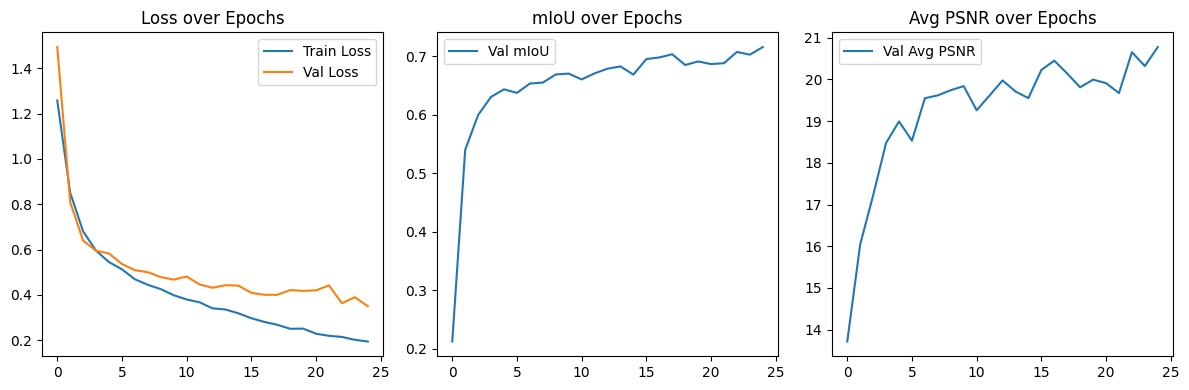

In [66]:
if __name__ == '__main__':
    # 1. Load dataset file paths
    train_img_files = sorted([os.path.join(TRAIN_IMG_DIR, f) for f in os.listdir(TRAIN_IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))])
    # Assume GT files have 'pix' in their name or correspond directly
    # Example: 0001.png -> 0001_pix.png or 0001.png (in GT folder)
    # Adjust this logic if your naming is different.
    train_gt_files = sorted([os.path.join(TRAIN_GT_DIR, f.replace('.png', '_pix.png')) # Example: 0001.png -> 0001_pix.png
                            for f in os.listdir(TRAIN_IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))])

    # Ensure all train_gt_files exist, otherwise the previous list comprehension might be faulty
    missing_gt_count = 0
    valid_train_img_files = []
    valid_train_gt_files = []
    for img_f, gt_f in zip(train_img_files, train_gt_files):
        if os.path.exists(gt_f):
            valid_train_img_files.append(img_f)
            valid_train_gt_files.append(gt_f)
        else:
            print(f"Warning: GT file not found for {img_f} tried {gt_f}")
            missing_gt_count+=1

    if missing_gt_count > 0:
        print(f"CRITICAL: {missing_gt_count} GT files are missing. Please check your dataset paths and naming conventions.")
        # exit() # Optional: exit if critical files are missing

    train_img_files = valid_train_img_files
    train_gt_files = valid_train_gt_files

    print(f"Found {len(train_img_files)} training images and {len(train_gt_files)} training masks.")


    # 2. Split train dataset into train and valid
    # (Make sure train_img_files and train_gt_files are correctly paired)
    img_train, img_val, mask_train, mask_val = train_test_split(
        train_img_files, train_gt_files, test_size=VALIDATION_SPLIT, random_state=RANDOM_SEED
    )
    print(f"Training samples: {len(img_train)}, Validation samples: {len(img_val)}")

    # Create Datasets and DataLoaders
    train_dataset = SofaDataset(img_train, mask_train, transform=image_transforms, target_size=IMG_SIZE)
    val_dataset = SofaDataset(img_val, mask_val, transform=image_transforms, target_size=IMG_SIZE)

    train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    # 3. Initialize Model
    # Replace UNet with your chosen model (VLTSeg or ONE-PEACE)
    # Ensure `n_classes` matches MODEL_NUM_OUTPUT_CLASSES
    print(f"Initializing model with {MODEL_NUM_OUTPUT_CLASSES} output classes.")
    model = UNet(n_channels=3, n_classes=MODEL_NUM_OUTPUT_CLASSES).to(DEVICE)
    # Example for loading a pre-trained VLTSeg/ONE-PEACE (conceptual)
    # model = load_vlts_one_peace_model(pretrained_weights_path='path/to/weights', num_classes=MODEL_NUM_OUTPUT_CLASSES)
    # model = model.to(DEVICE)

    # 4. Set training parameters
    criterion = nn.CrossEntropyLoss() # Common for multi-class segmentation
    optimizer = optim.Adam(model.parameters(), lr=LEARNING_RATE)

    # 5. Execute Training
    print("Starting training...")
    train_history = train_and_validate_model(model, train_loader, val_loader, criterion, optimizer, NUM_EPOCHS, DEVICE,
                                MODEL_SAVE_PATH, VALIDATION_RESULTS_PATH)


    # --- Plot training history  ---
    plot_training_history(train_history, OUTPUT_DIR)




Starting testing...

Loaded model from ./output_results\models\best_model.pth for testing.
  Resizing prediction for 0401 from (256, 256) to (1488, 1852)...
  Saved prediction (original size) for 0401 to ./output_results\predict\0401_pred.png
Saved test image(input, output, GT) to ./output_results\compare\0401_compare.png
  Saved test (input, output, GT) for 0401 to ./output_results\compare path
  Resizing prediction for 0402 from (256, 256) to (1274, 1472)...
  Saved prediction (original size) for 0402 to ./output_results\predict\0402_pred.png
Saved test image(input, output, GT) to ./output_results\compare\0402_compare.png
  Saved test (input, output, GT) for 0402 to ./output_results\compare path
  Resizing prediction for 0403 from (256, 256) to (1614, 1323)...
  Saved prediction (original size) for 0403 to ./output_results\predict\0403_pred.png
Saved test image(input, output, GT) to ./output_results\compare\0403_compare.png
  Saved test (input, output, GT) for 0403 to ./output_resul

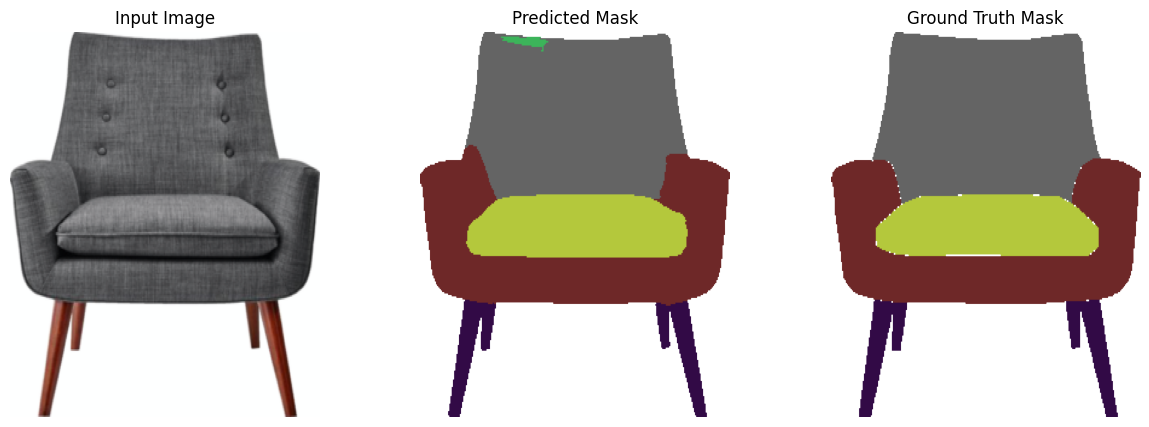

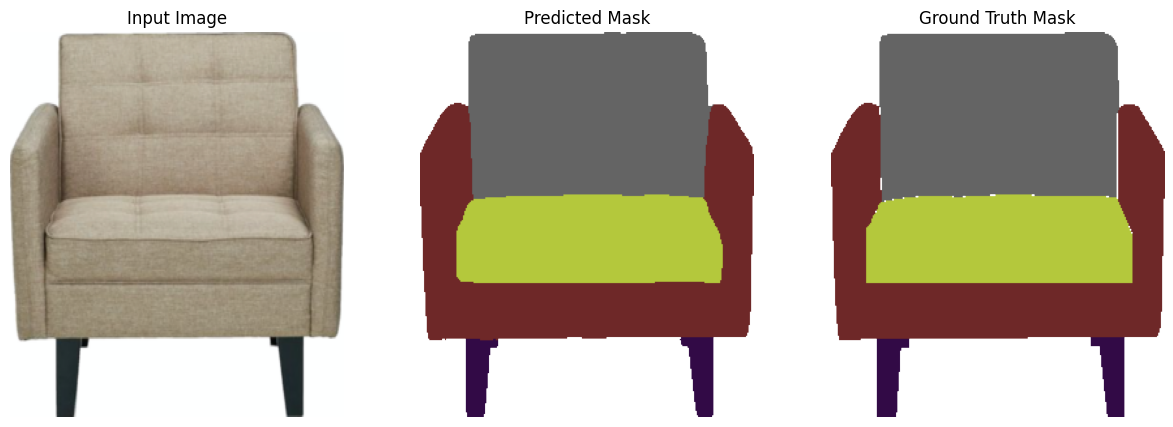

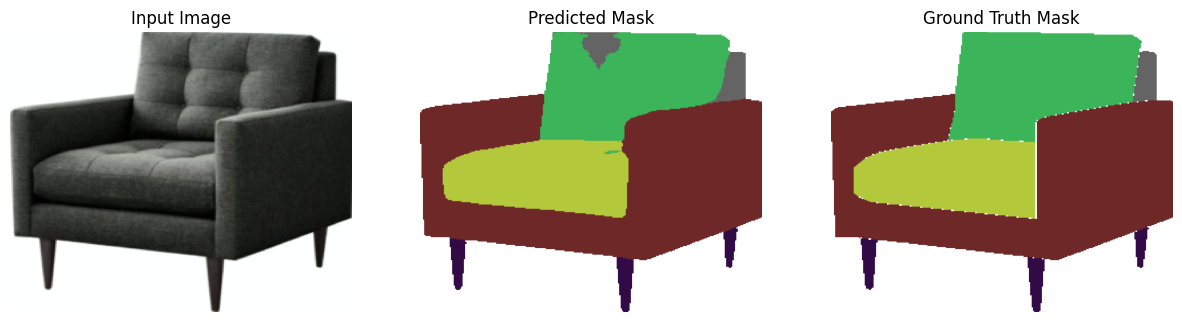

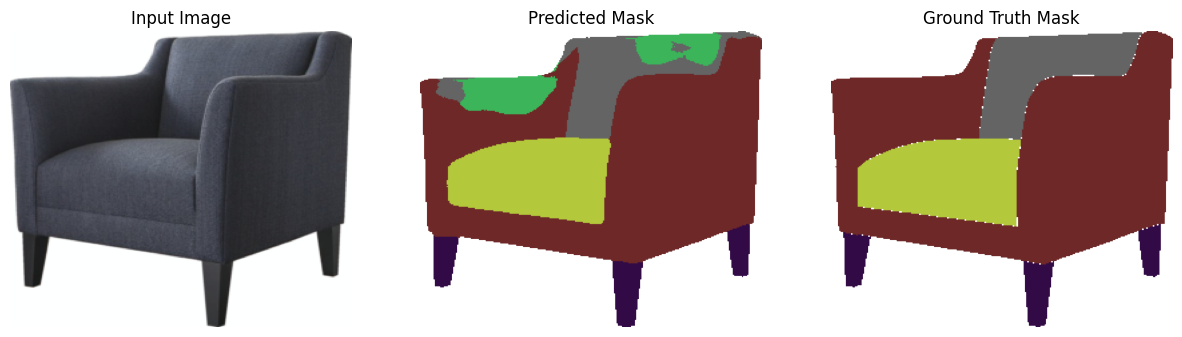

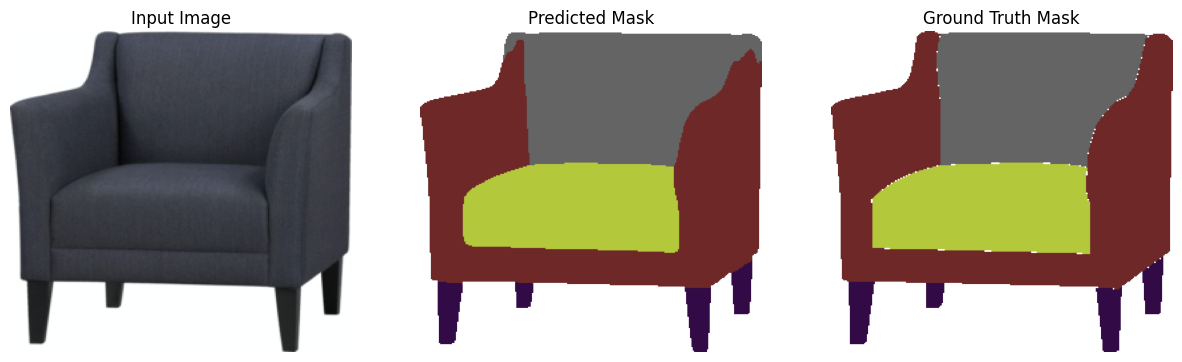

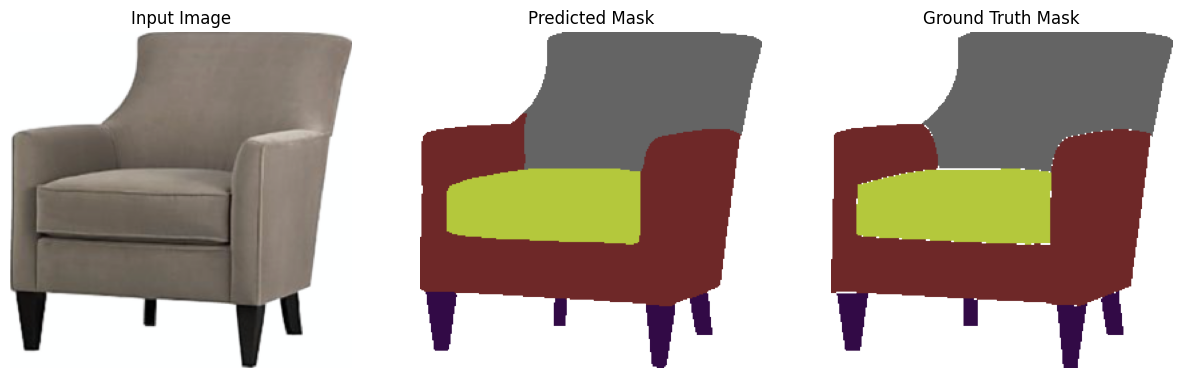

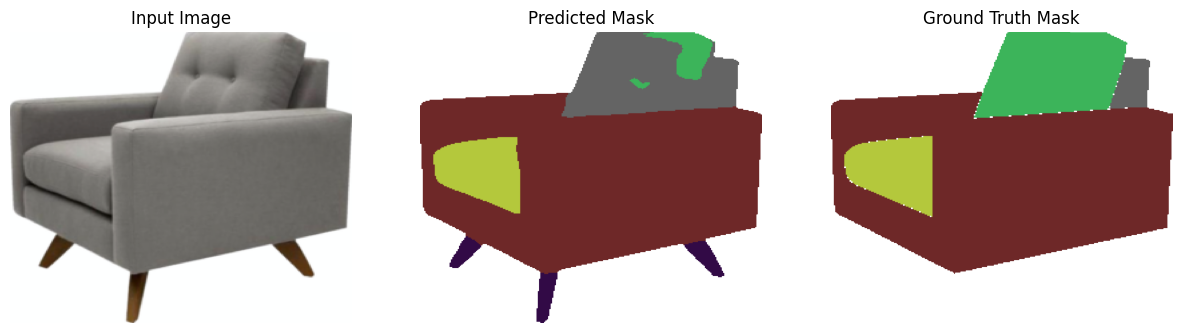

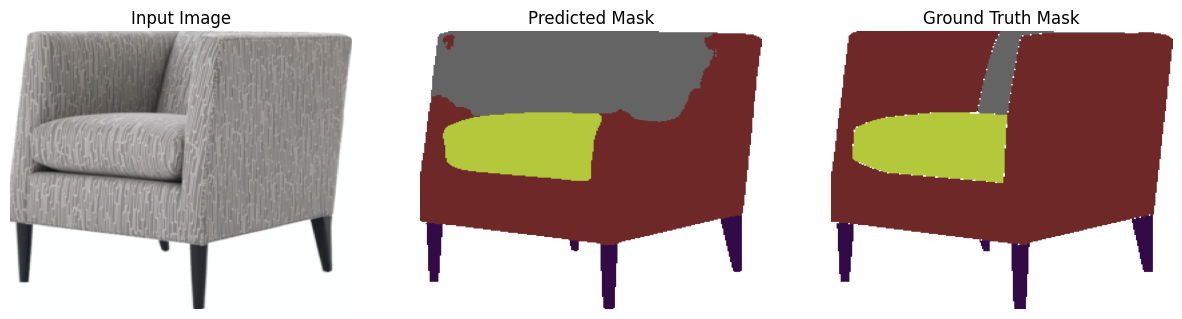

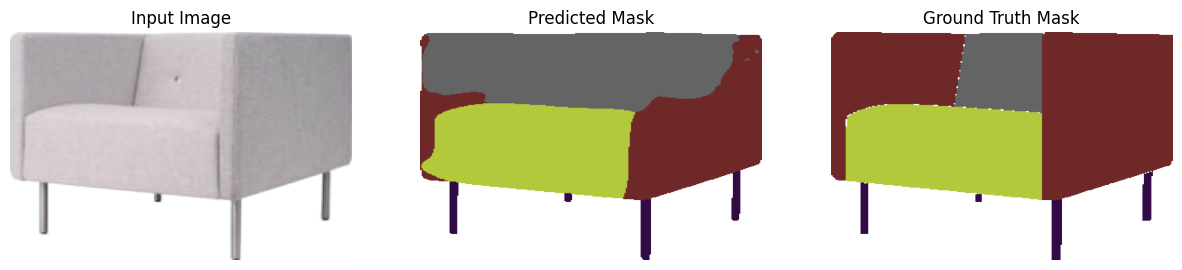

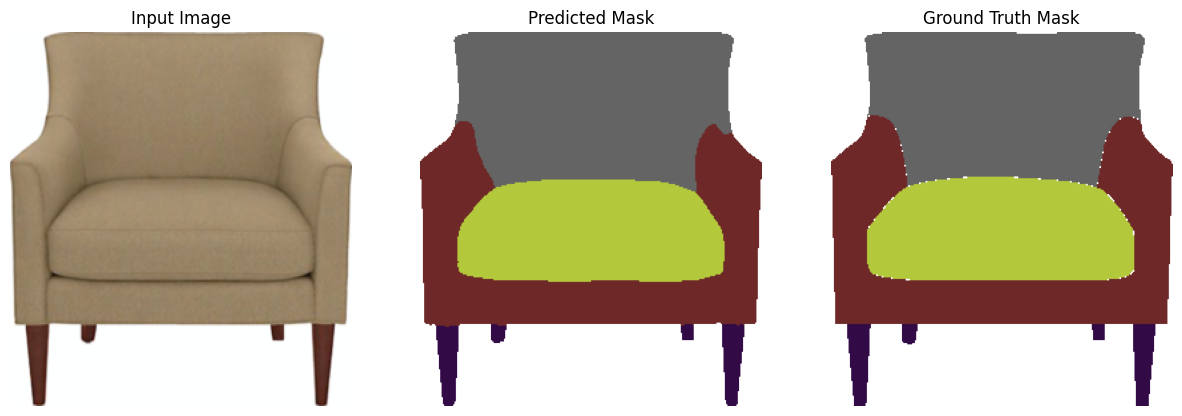

In [67]:

    # 6. Perform Testing
    print("\nStarting testing...")
    test_img_files = sorted([os.path.join(TEST_IMG_DIR, f) for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))])
    test_gt_files = sorted([os.path.join(TEST_GT_DIR, f.replace('.png', '_pix.png'))
                           for f in os.listdir(TEST_IMG_DIR) if f.endswith(('.png', '.jpg', '.jpeg'))])

    valid_test_img_files = []
    valid_test_gt_files = []
    for img_f, gt_f in zip(test_img_files, test_gt_files):
        if os.path.exists(gt_f):
            valid_test_img_files.append(img_f)
            valid_test_gt_files.append(gt_f)
        else:
            print(f"Warning: Test GT file not found for {img_f}")
            
    test_img_files = valid_test_img_files
    test_gt_files = valid_test_gt_files

    test_dataset = SofaDataset(test_img_files, test_gt_files, transform=image_transforms, target_size=IMG_SIZE)
    test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False) # Usually batch_size=1 for testing if saving individual images

    best_model_path = os.path.join(MODEL_SAVE_PATH, 'best_model.pth')
    test_model(model, test_loader, DEVICE, best_model_path, TEST_PREDICTIONS_PATH, TEST_PREDICTIONS_COMPARE_PATH)

    print("\nProcess finished. Check the output directory for results.")

